In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Загрузка набора данных
df = pd.read_csv('bike.csv')


y = df['cnt'] # выбираем целевую переменную (количественная)
X = df.drop('cnt', axis=1) # переменные для проверки влияния
X = X.drop('instant', axis=1)

In [2]:
X

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1/1/2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000
1,1/1/2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000
2,1/1/2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000
3,1/1/2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000
4,1/1/2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,12/31/2012,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642
17375,12/31/2012,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642
17376,12/31/2012,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642
17377,12/31/2012,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343


In [3]:
# Создаем копию данных
category_columns: list[str] = X.select_dtypes(include=['object']).columns # собираем колонки помеченные как object

# Применяем One-Hot Encoding к категориальным столбцам, исключая первую категорию (drop_first=True)
X = pd.get_dummies(X, columns=category_columns,drop_first=True)

In [4]:
X

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,dteday_9/5/2011,dteday_9/5/2012,dteday_9/6/2011,dteday_9/6/2012,dteday_9/7/2011,dteday_9/7/2012,dteday_9/8/2011,dteday_9/8/2012,dteday_9/9/2011,dteday_9/9/2012
0,1,0,1,0,0,6,0,1,0.24,0.2879,...,False,False,False,False,False,False,False,False,False,False
1,1,0,1,1,0,6,0,1,0.22,0.2727,...,False,False,False,False,False,False,False,False,False,False
2,1,0,1,2,0,6,0,1,0.22,0.2727,...,False,False,False,False,False,False,False,False,False,False
3,1,0,1,3,0,6,0,1,0.24,0.2879,...,False,False,False,False,False,False,False,False,False,False
4,1,0,1,4,0,6,0,1,0.24,0.2879,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,1,12,19,0,1,1,2,0.26,0.2576,...,False,False,False,False,False,False,False,False,False,False
17375,1,1,12,20,0,1,1,2,0.26,0.2576,...,False,False,False,False,False,False,False,False,False,False
17376,1,1,12,21,0,1,1,1,0.26,0.2576,...,False,False,False,False,False,False,False,False,False,False
17377,1,1,12,22,0,1,1,1,0.26,0.2727,...,False,False,False,False,False,False,False,False,False,False


In [5]:
df_corr_test = X.copy()

# Добавляем целевую переменную в копию данных
df_corr_test['y'] = y
df_corr_test
     

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,dteday_9/5/2012,dteday_9/6/2011,dteday_9/6/2012,dteday_9/7/2011,dteday_9/7/2012,dteday_9/8/2011,dteday_9/8/2012,dteday_9/9/2011,dteday_9/9/2012,y
0,1,0,1,0,0,6,0,1,0.24,0.2879,...,False,False,False,False,False,False,False,False,False,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,...,False,False,False,False,False,False,False,False,False,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,...,False,False,False,False,False,False,False,False,False,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,...,False,False,False,False,False,False,False,False,False,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,...,False,False,False,False,False,False,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,1,12,19,0,1,1,2,0.26,0.2576,...,False,False,False,False,False,False,False,False,False,119
17375,1,1,12,20,0,1,1,2,0.26,0.2576,...,False,False,False,False,False,False,False,False,False,89
17376,1,1,12,21,0,1,1,1,0.26,0.2576,...,False,False,False,False,False,False,False,False,False,90
17377,1,1,12,22,0,1,1,1,0.26,0.2727,...,False,False,False,False,False,False,False,False,False,61


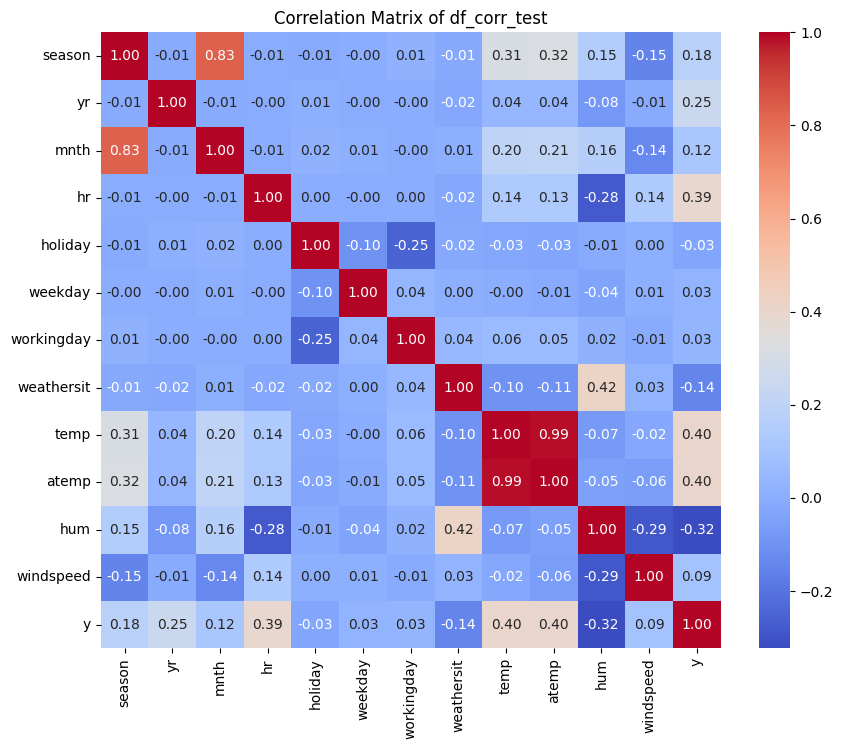

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Предположим, что у вас уже есть DataFrame под названием df_corr_test
# Выводим матрицу корреляции (только для числовых столбцов)
correlation_matrix = df_corr_test.select_dtypes(['int', 'float']).corr()

# Отображаем матрицу корреляции с помощью тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of df_corr_test")
plt.show()

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def resolve_regression(X, y, regularization=None):
    """
    Выполняет регрессию с учетом регуляризации.

    Parameters:
    - X: Входные данные (признаки).
    - y: Целевые значения.
    - regularization: Тип регуляризации ('l1', 'l2', None). Если None, используется обычная линейная регрессия.
    """
    # Разделение данных на обучающую и тестовую выборки (80% / 20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Инициализация модели в зависимости от типа регуляризации
    if regularization == 'l1':
        model = Lasso() # L1-регуляризация (Lasso)
    elif regularization == 'l2':
        model = Ridge() # L2-регуляризация (Ridge)
    else:
        model = LinearRegression() # Линейная регрессия без регуляризации

    # Обучение модели
    model.fit(X_train, y_train)

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)

    # Вычисление метрик качества
    mae = mean_absolute_error(y_test, y_pred) # Средняя абсолютная ошибка
    mse = mean_squared_error(y_test, y_pred)  # Средняя квадратичная ошибка
    r2 = r2_score(y_test, y_pred)             # Коэффициент детерминации (R^2)

    # Вывод результатов
    print(f"Regularization: {regularization}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")

    return model, X_train, X_test, y_train, y_test

In [8]:
resolve_regression(X, y)
None

Regularization: None
Mean Absolute Error (MAE): 103.69
Mean Squared Error (MSE): 19088.04
R^2 Score: 0.40


In [9]:
resolve_regression(X[['temp', 'atemp', 'hum']], y)
None

Regularization: None
Mean Absolute Error (MAE): 115.04
Mean Squared Error (MSE): 23491.19
R^2 Score: 0.26


In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Columns: 742 entries, season to dteday_9/9/2012
dtypes: bool(730), float64(4), int64(8)
memory usage: 13.7 MB


In [11]:
import pandas as pd
import numpy as np

def select_features_correlation(X, y, max_features=5):
    # Вычисляем корреляцию признаков с целевой переменной
    correlation = X.apply(lambda col: np.abs(col.corr(y)))

    # Отбираем top-N признаков с наибольшей корреляцией
    top_features = correlation.nlargest(max_features).index

    # Возвращаем X и y с отобранными признаками
    return X[top_features], y

In [12]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

def select_features_rfe(X, y, max_features=5):
    # Инициализация модели линейной регрессии
    model = LinearRegression()

    # RFE с указанным количеством признаков
    selector = RFE(model, n_features_to_select=max_features)
    selector = selector.fit(X, y)

    # Отбор признаков
    selected_features = X.columns[selector.support_]

    # Возвращаем X и y с отобранными признаками
    return X[selected_features], y

In [13]:
# Предположим, что у вас есть данные X и y
# Используем отбор на основе корреляции
X_selected_corr, y_selected_corr = select_features_correlation(X, y, max_features=5)

# Используем отбор с помощью RFE
X_selected_rfe, y_selected_rfe = select_features_rfe(X, y, max_features=5)
     

In [14]:
resolve_regression(X_selected_corr, y_selected_corr)
None
     

Regularization: None
Mean Absolute Error (MAE): 105.07
Mean Squared Error (MSE): 19674.39
R^2 Score: 0.38


In [15]:
resolve_regression(X_selected_rfe, y_selected_rfe)
None
     

Regularization: None
Mean Absolute Error (MAE): 114.65
Mean Squared Error (MSE): 23366.99
R^2 Score: 0.26


Regularization: None
Mean Absolute Error (MAE): 114.65
Mean Squared Error (MSE): 23366.99
R^2 Score: 0.26


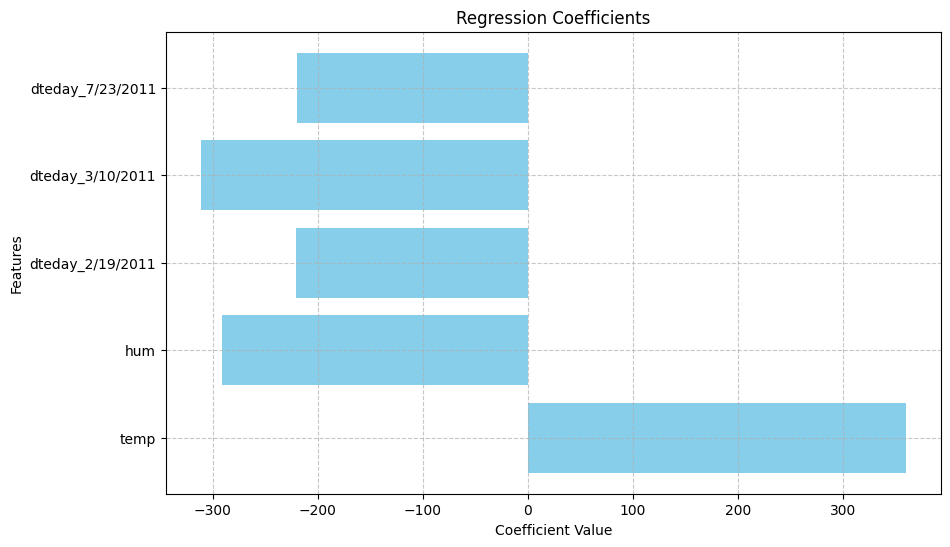

In [16]:
import matplotlib.pyplot as plt

def plot_regression_coefficients(model, feature_names):
    # Извлекаем коэффициенты регрессии
    coefficients = model.coef_

    # Создаем столбчатую диаграмму для визуализации коэффициентов
    plt.figure(figsize=(10, 6))
    plt.barh(feature_names, coefficients, color='skyblue')
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    plt.title("Regression Coefficients")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Пример использования:
# Сначала выполним линейную регрессию
model, X_train, X_test, y_train, y_test = resolve_regression(X_selected_rfe, y_selected_rfe, None)

# Визуализация коэффициентов регрессии
plot_regression_coefficients(model, X_selected_rfe.columns)

In [17]:

# Выбираем числовые признаки
numeric_features = X_selected_rfe.select_dtypes(include=['int64', 'float64']).columns.tolist()
# ВНИМАНИЕ: тут отбираются только float, если у вас не категориальные признаки имеют тип int - нужно исправить (например, в ручную указать нужные столбцы)

# Инициализируем scaler
scaler = MinMaxScaler()

# Применяем нормализацию
X_selected_rfe[numeric_features] = scaler.fit_transform(X_selected_rfe[numeric_features])

/tmp/ipykernel_29952/159462087.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected_rfe[numeric_features] = scaler.fit_transform(X_selected_rfe[numeric_features])


In [18]:
X_selected_rfe

,temp,hum,dteday_2/19/2011,dteday_3/10/2011,dteday_7/23/2011
0,0.224490,0.81,False,False,False
1,0.204082,0.80,False,False,False
2,0.204082,0.80,False,False,False
3,0.224490,0.75,False,False,False
4,0.224490,0.75,False,False,False
...,...,...,...,...,...
17374,0.244898,0.60,False,False,False
17375,0.244898,0.60,False,False,False
17376,0.244898,0.60,False,False,False
17377,0.244898,0.56,False,False,False


Regularization: None
Mean Absolute Error (MAE): 114.65
Mean Squared Error (MSE): 23366.99
R^2 Score: 0.26


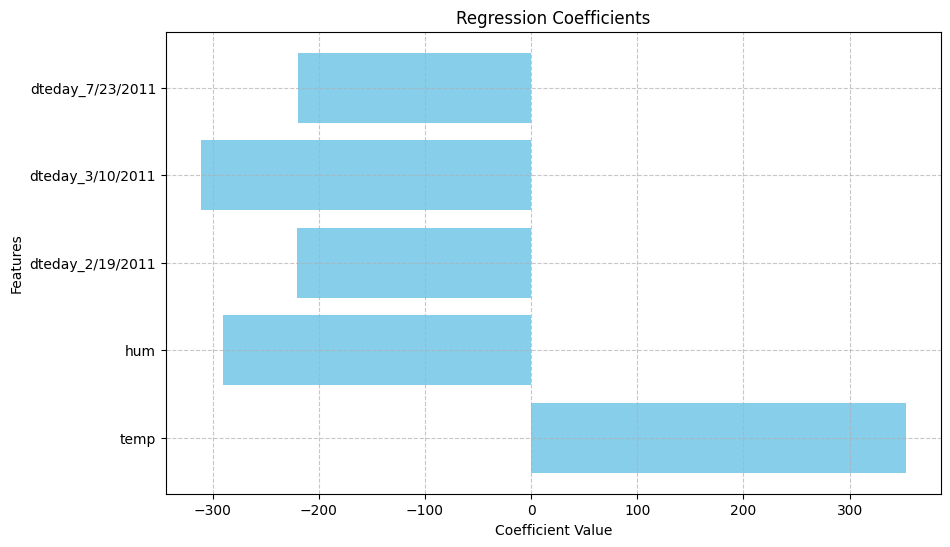

In [19]:

# Сначала выполним линейную регрессию
model, X_train, X_test, y_train, y_test = resolve_regression(X_selected_rfe, y_selected_rfe)

# Визуализация коэффициентов регрессии
plot_regression_coefficients(model, X_selected_rfe.columns)

In [20]:
# Предсказание на тестовой выборке
y_pred = model.predict(X_test)

# Вычисление метрик качества
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Вывод метрик
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Absolute Error (MAE): 114.65
Mean Squared Error (MSE): 23366.99
R^2 Score: 0.26


In [21]:
X

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,dteday_9/5/2011,dteday_9/5/2012,dteday_9/6/2011,dteday_9/6/2012,dteday_9/7/2011,dteday_9/7/2012,dteday_9/8/2011,dteday_9/8/2012,dteday_9/9/2011,dteday_9/9/2012
0,1,0,1,0,0,6,0,1,0.24,0.2879,...,False,False,False,False,False,False,False,False,False,False
1,1,0,1,1,0,6,0,1,0.22,0.2727,...,False,False,False,False,False,False,False,False,False,False
2,1,0,1,2,0,6,0,1,0.22,0.2727,...,False,False,False,False,False,False,False,False,False,False
3,1,0,1,3,0,6,0,1,0.24,0.2879,...,False,False,False,False,False,False,False,False,False,False
4,1,0,1,4,0,6,0,1,0.24,0.2879,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,1,12,19,0,1,1,2,0.26,0.2576,...,False,False,False,False,False,False,False,False,False,False
17375,1,1,12,20,0,1,1,2,0.26,0.2576,...,False,False,False,False,False,False,False,False,False,False
17376,1,1,12,21,0,1,1,1,0.26,0.2576,...,False,False,False,False,False,False,False,False,False,False
17377,1,1,12,22,0,1,1,1,0.26,0.2727,...,False,False,False,False,False,False,False,False,False,False


Regularization: l1
Mean Absolute Error (MAE): 104.60
Mean Squared Error (MSE): 19538.77
R^2 Score: 0.38


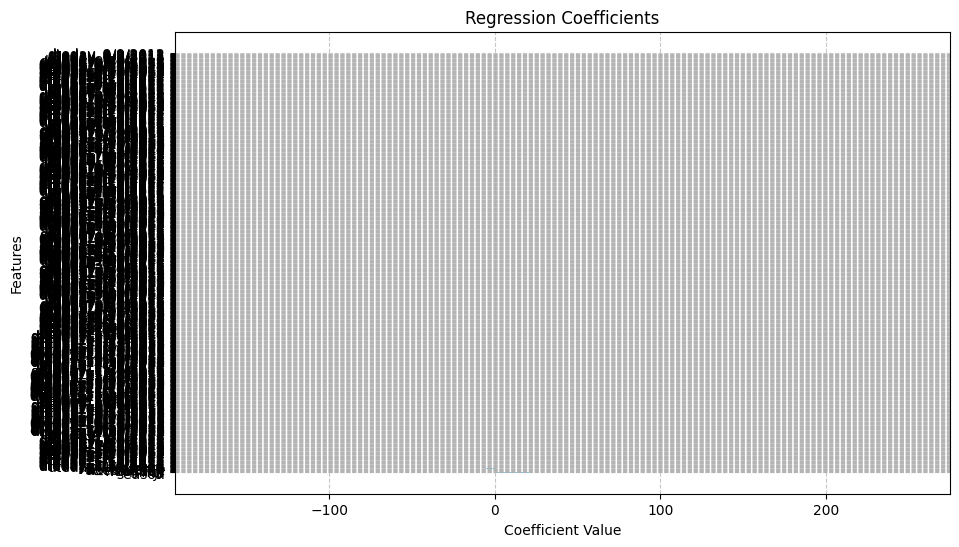

In [22]:
# L1-регуляризация
model, _, _, _, _ = resolve_regression(X, y, regularization='l1')
None

# Визуализация коэффициентов регрессии
plot_regression_coefficients(model, X.columns)

Regularization: l2
Mean Absolute Error (MAE): 103.51
Mean Squared Error (MSE): 19020.75
R^2 Score: 0.40


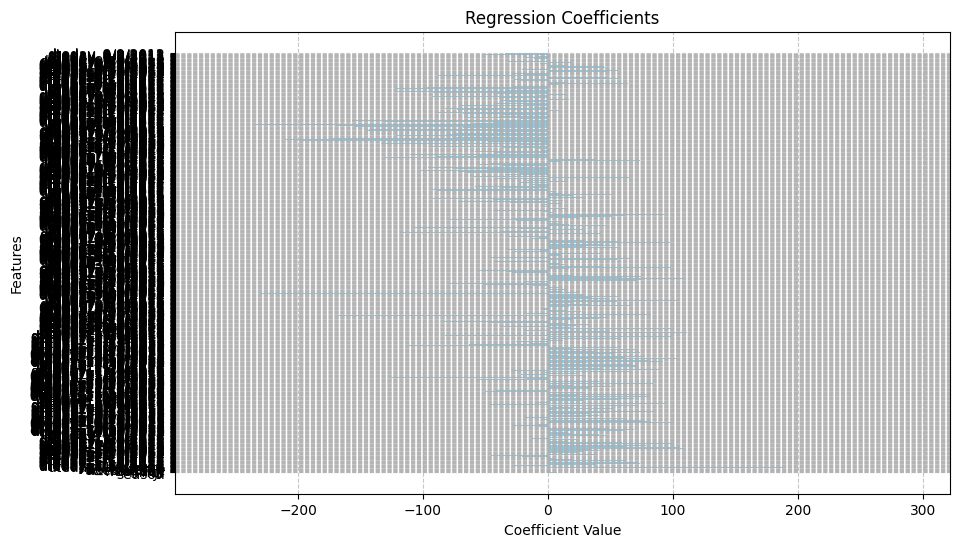

In [23]:
# L2-регуляризация
model, _, _, _, _ = resolve_regression(X, y, regularization='l2')
None

# Визуализация коэффициентов регрессии
plot_regression_coefficients(model, X.columns)